In [11]:
# Load: df, attributions/cossim, k-cee lib (1059), p-val lib, MPRA diffs.
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import ttest_ind

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap

eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

cossim = em.cosine_similarity(mode='importance', zscore=True)

# k-cee lib (1059 = 3 x 353 from EI_1 var x r selection)
with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
kcee_idx = target_lib['df']['seq_idx'].values

# p-val lib via Welch on per-rep MPRA log2_ratio
MPRA_DIR = os.path.join(REPO, 'data', 'full_joint_mpra')
COLS = ['cell','rep','name','dna','rna','ratio','log2_ratio','n_bc']
def _load(cell):
    return pd.concat([pd.read_csv(f, sep='\t', header=None, names=COLS)
                      for f in sorted(glob.glob(f'{MPRA_DIR}/{cell}/{cell}_rep*.tsv'))],
                     ignore_index=True)
hep_w = _load('HepG2').pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = _load('K562' ).pivot_table(index='name', columns='rep', values='log2_ratio')
shared = hep_w.index.intersection(k_w.index)
H, K = hep_w.loc[shared].values, k_w.loc[shared].values
ok = np.isfinite(H).all(1) & np.isfinite(K).all(1)
_, pv = ttest_ind(H[ok], K[ok], axis=1, equal_var=False)
diffs = df['name'].map(dict(zip(shared[ok], H[ok].mean(1) - K[ok].mean(1)))).values.astype(float)
pvals = df['name'].map(dict(zip(shared[ok], pv))).values.astype(float)

fin = np.isfinite(diffs) & np.isfinite(pvals)
bioinfo_idx = np.where(fin & (pvals < 0.05) & (np.abs(diffs) > 2.0))[0]

print(f'k-cee lib: {len(kcee_idx)} | p-val lib: {len(bioinfo_idx)}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
k-cee lib: 1059 | p-val lib: 956


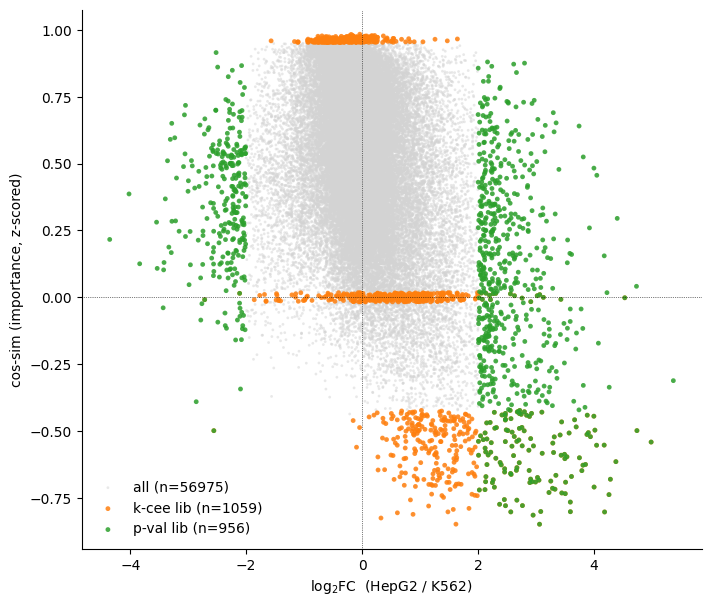

In [12]:
# Full lib (gray) with k-cee lib (orange) and p-val lib (green) highlighted.
lfc = (df['HepG2_log2FC'] - df['K562_log2FC']).values
fin = np.isfinite(cossim) & np.isfinite(lfc)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(lfc[fin], cossim[fin], s=4, c='lightgray', alpha=0.5,
           edgecolors='none', label=f'all (n={fin.sum()})', rasterized=True)
ax.scatter(lfc[kcee_idx], cossim[kcee_idx], s=12, c='#ff7f0e',
           alpha=0.85, edgecolors='none', label=f'k-cee lib (n={len(kcee_idx)})')
ax.scatter(lfc[bioinfo_idx], cossim[bioinfo_idx], s=12, c='#2ca02c',
           alpha=0.85, edgecolors='none', label=f'p-val lib (n={len(bioinfo_idx)})')
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('log$_2$FC  (HepG2 / K562)')
ax.set_ylabel('cos-sim (importance, z-scored)')
ax.legend(frameon=False, loc='lower left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.show()

In [91]:
# Pick a diff-diff seq: both H/K highly active, |log2FC|~0, NOT in p-val lib.
SEED       = 5555
LFC_TOL    = 5
ACTIVE_MIN = 1
lib_df = target_lib['df']
hep = df['HepG2_log2FC'].values
k62 = df['K562_log2FC'].values

mask = (lib_df['condition'].values == 'diff-diff') & \
       ~np.isin(lib_df['seq_idx'].values, bioinfo_idx)
cand = lib_df['seq_idx'].values[mask]
cand = cand[(np.abs(lfc[cand]) < LFC_TOL) &
            (hep[cand] > ACTIVE_MIN) & (k62[cand] > ACTIVE_MIN)]
print(f'diff-diff candidates: {len(cand)}  '
      f'(|lfc|<{LFC_TOL}, both>{ACTIVE_MIN}, not in p-val lib)')

s = int(np.random.default_rng(SEED).choice(cand))
sel = {'diff-diff': s}
print(f'  seq_idx={s}  name={df.loc[s,"name"]}'
      f'  H={hep[s]:.2f}  K={k62[s]:.2f}'
      f'  log2FC={lfc[s]:+.3f}  cossim={cossim[s]:+.3f}')

diff-diff candidates: 1  (|lfc|<5, both>1, not in p-val lib)
  seq_idx=45860  name=HepG2_DNasePeakNoPromoter37453  H=1.41  K=1.30  log2FC=+0.116  cossim=-0.009



=== diff-diff  seq_idx=45860 ===
Eigendecomposed 1 sequences (enhancer only, 230bp)
  HepG2: 8 motif hits (p<0.05)
  K562: 7 motif hits (p<0.05)
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
annotate_tf_binding(gaussian): 11/15 TF assignments changed across 1 sequences (sigma=0.642)
  HepG2: 8 hits
    [ 94-108] NR4A1(p=2.0e-05), Nr1H4(p=3.2e-05), NR2F2(p=4.9e-05)  (enhancer)
    [ 86-100] BCL11A(p=1.7e-03), NR2F6(p=2.4e-03), NR2F1(p=3.2e-03)  (enhancer)
    [ 36- 50] Ebf2(p=3.6e-03), EBF3(p=4.8e-03), SP5(p=5.3e-03)  (enhancer)
    [ 72- 86] Ahr::Arnt(p=2.9e-04), NFIC::TLX1(p=1.5e-03), NFIC(p=1.9e-03)  (enhancer)
    [102-116] NRL(p=1.3e-04), MAFF(p=2.3e-04), Mafb(p=6.0e-04)  (enhancer)
    [168-182] JDP2(p=2.4e-04), ATF7(p=3.6e-04), ATF3(p=5.5e-04)  (enhancer)
    [121-135] GATA6(p=5.6e-05), TRPS1(p=7.3e-05), Gata3(p=7.3e-05)  (enhancer)
    [ 28- 42] ZNF850(p=1.9e-05), ZNF148(p=6.2e-04), MAZ(p=6.3e

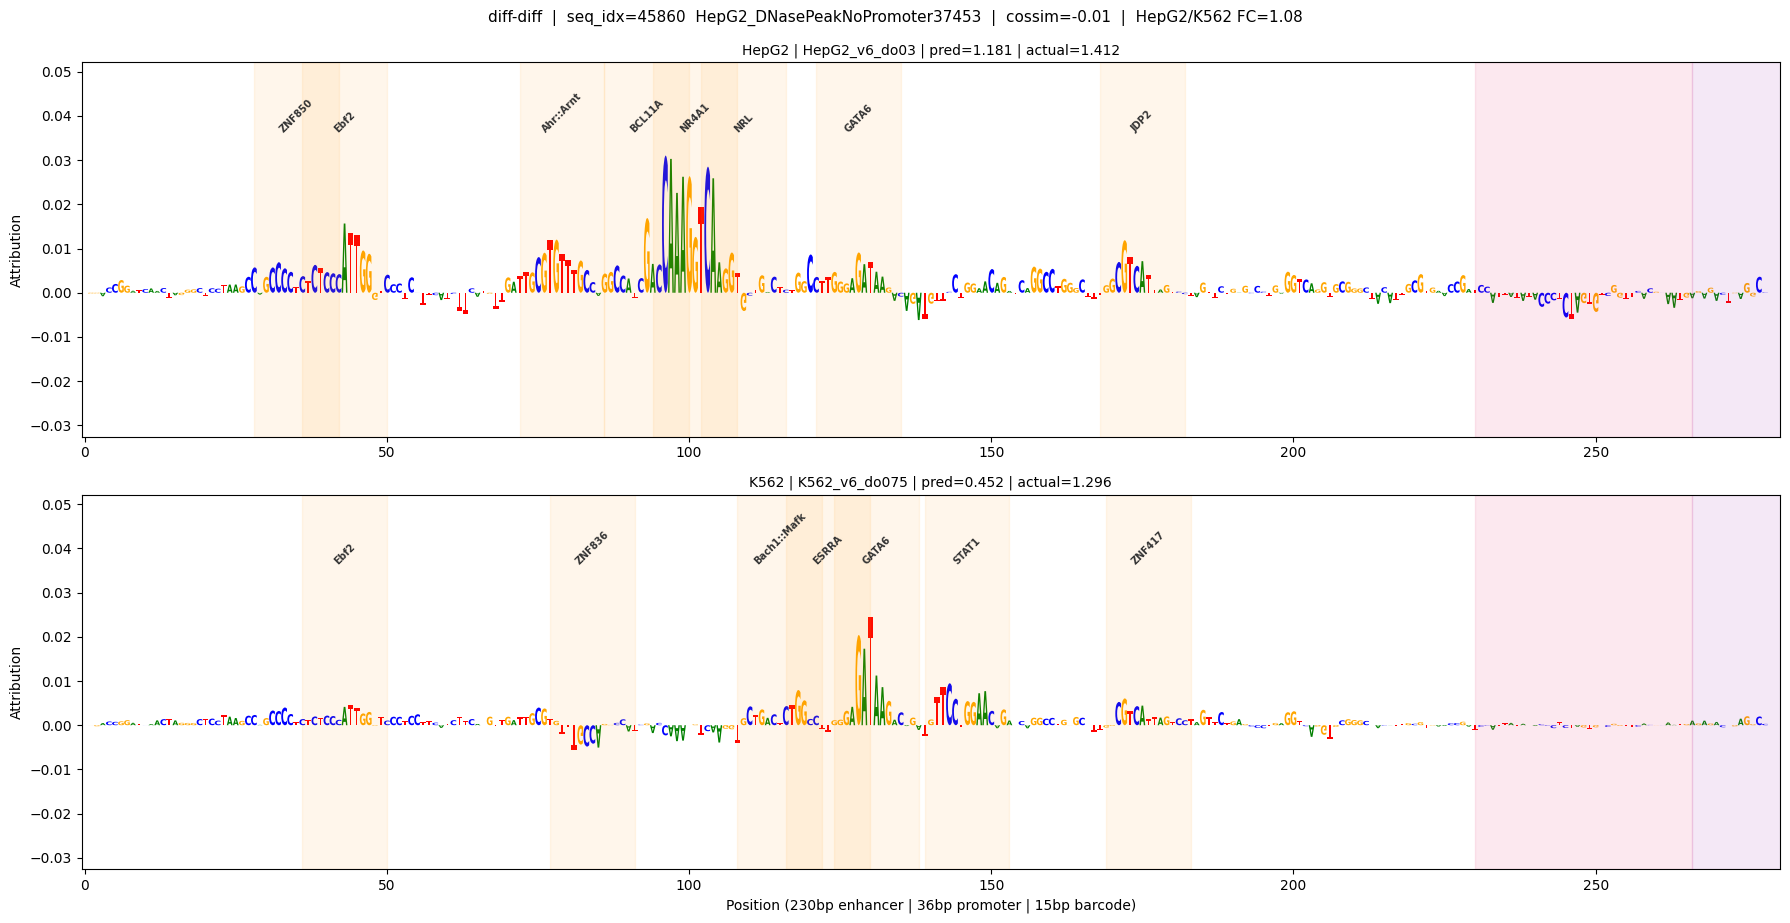

In [93]:
# Annotated logos for each selected seq (same-diff and diff-diff).
import copy

def annotate_one(s):
    em_sel = copy.copy(em)
    em_sel.cell_types = ['HepG2', 'K562']
    em_sel.X         = em.X[s:s+1]
    em_sel.constructs = [em.constructs[s]]
    em_sel.attr      = {ct: em.attr[ct][s:s+1]      for ct in em_sel.cell_types}
    em_sel.attr_hyp  = {ct: em.attr_hyp[ct][s:s+1]  for ct in em_sel.cell_types}
    em_sel.importance = {ct: em.importance[ct][s:s+1] for ct in em_sel.cell_types}
    em_sel.predictions = {ct: em.predictions[ct][s:s+1] for ct in em_sel.cell_types}
    em_sel.actual    = {ct: df[f'{ct}_log2FC'].values[s:s+1] for ct in em_sel.cell_types}
    em_sel.eigendecompose()
    em_sel.annotate_motifs(window_size=10, flank=2)
    em_sel.load_expression()
    em_sel.annotate_tf_binding(method='gaussian')
    return em_sel

for cond, s in sel.items():
    print(f'\n=== {cond}  seq_idx={s} ===')
    em_sel = annotate_one(s)
    em_sel.show_motifs(seq_idx=0)
    fig, axes = em_sel.plot_attr_logos_with_motifs(seq_idx=0)
    fc = 2.0 ** lfc[s]
    fig.suptitle(f'{cond}  |  seq_idx={s}  {df.loc[s,"name"]}  |  '
                 f'cossim={cossim[s]:+.2f}  |  HepG2/K562 FC={fc:.2f}',
                 fontsize=11, y=1.02)
    plt.show()

In [139]:
# Pick a same-diff seq with large fold change AND very negative cossim,
# in k-cee lib (already implicit) but NOT in p-val lib.
SEED2   = 11111111111
LFC_MIN = 0.00
COS_MAX = -0.83

mask2 = (lib_df['condition'].values == 'same-diff') & \
        ~np.isin(lib_df['seq_idx'].values, bioinfo_idx)
cand2 = lib_df['seq_idx'].values[mask2]
cand2 = cand2[(np.abs(lfc[cand2]) > LFC_MIN) & (cossim[cand2] < COS_MAX)]
print(f'same-diff candidates: {len(cand2)}  '
      f'(|lfc|>{LFC_MIN}, cossim<{COS_MAX}, not in p-val lib)')

s2 = int(np.random.default_rng(SEED2).choice(cand2))
sel2 = {'same-diff': s2}
print(f'  seq_idx={s2}  name={df.loc[s2,"name"]}'
      f'  H={hep[s2]:.2f}  K={k62[s2]:.2f}'
      f'  log2FC={lfc[s2]:+.3f}  cossim={cossim[s2]:+.3f}')

same-diff candidates: 1  (|lfc|>0.0, cossim<-0.83, not in p-val lib)
  seq_idx=38571  name=HepG2_DNasePeakNoPromoter61479  H=0.86  K=-0.76  log2FC=+1.618  cossim=-0.849



=== same-diff  seq_idx=38571 ===
Eigendecomposed 1 sequences (enhancer only, 230bp)
  HepG2: 7 motif hits (p<0.05)
  K562: 7 motif hits (p<0.05)
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
annotate_tf_binding(gaussian): 9/14 TF assignments changed across 1 sequences (sigma=0.642)
  HepG2: 7 hits
    [148-162] LMX1B(p=1.5e-03), SATB1(p=2.5e-03), TIGD4(p=3.4e-03)  (enhancer)
    [ 90-104] HNF1B(p=6.2e-04), HNF1A(p=7.8e-04), HMBOX1(p=1.4e-03)  (enhancer)
    [137-151] IRF9(p=4.4e-03), ZBED2(p=5.6e-03), Foxj3(p=6.9e-03)  (enhancer)
    [ 98-112] Msgn1(p=5.6e-03), SALL3(p=6.4e-03), SOX10(p=7.1e-03)  (enhancer)
    [116-130] ATF4(p=7.9e-04), CEBPG(p=1.3e-03), ZNF510(p=2.7e-03)  (enhancer)
    [ 82- 96] HSF2(p=3.1e-03), HSF1(p=3.2e-03), FLYWCH1(p=4.1e-03)  (enhancer)
    [108-122] Zic2(p=5.5e-03), MYB(p=8.0e-03), ZIC1(p=1.1e-02)  (enhancer)
  K562: 7 hits
    [146-160] HNF1B(p=8.1e-05), HNF1A(p=1.6e-04), 

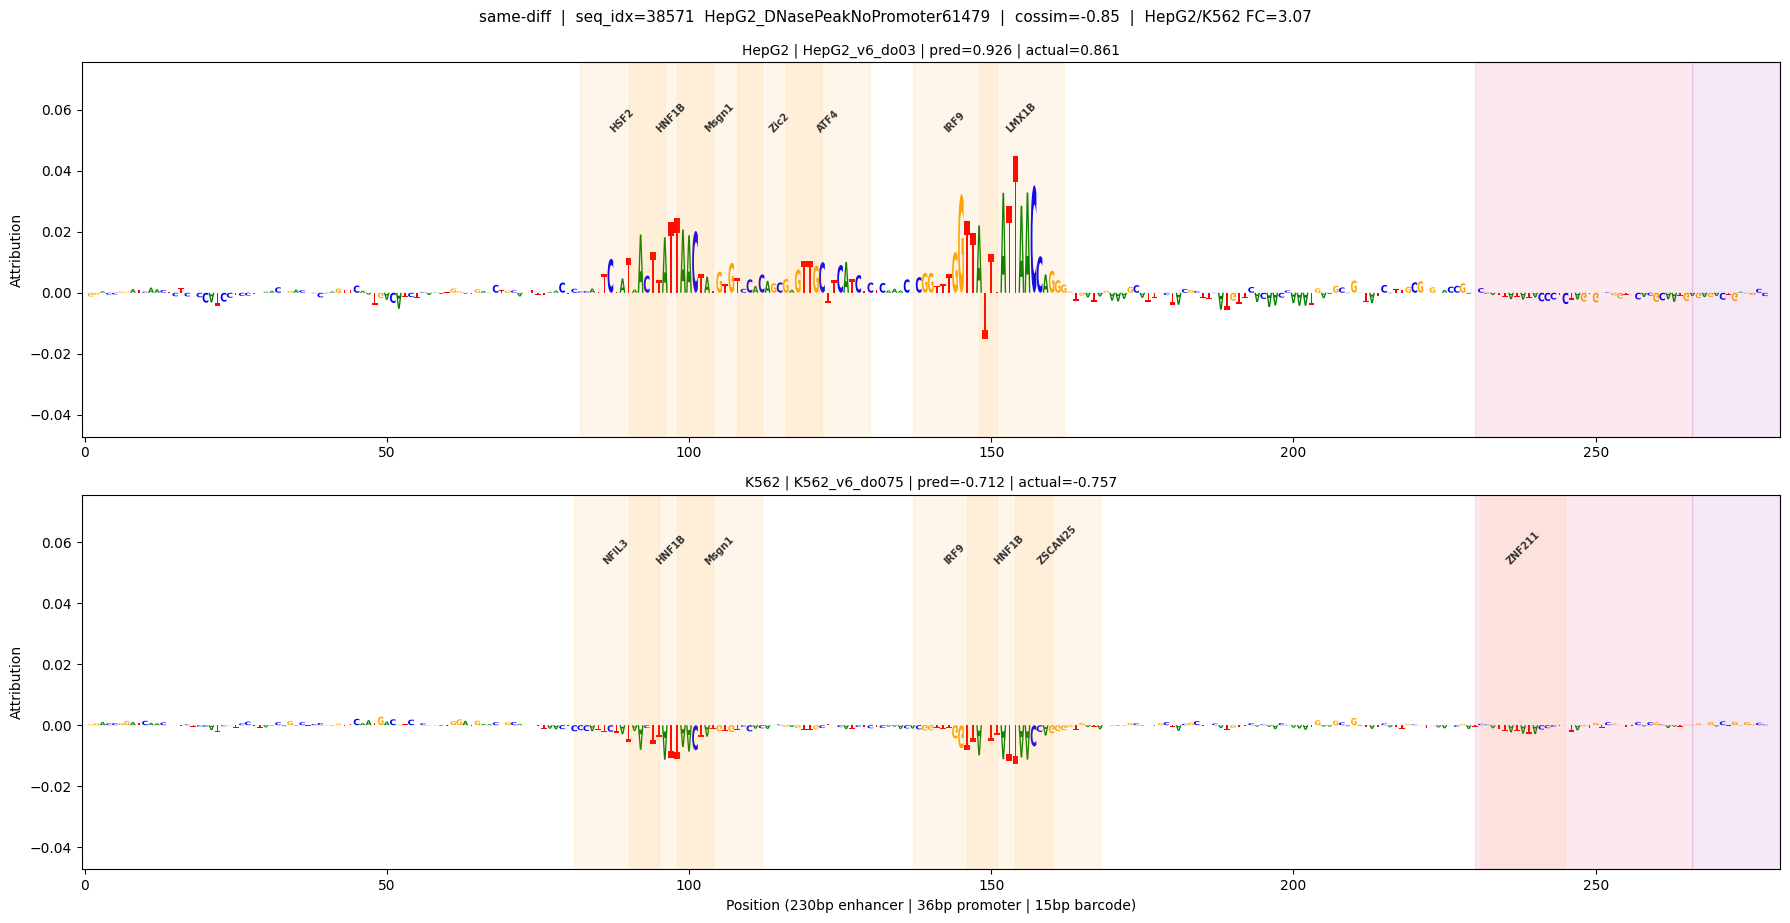

In [140]:
# Annotated logos for the same-diff selection.
for cond, s in sel2.items():
    print(f'\n=== {cond}  seq_idx={s} ===')
    em_sel = annotate_one(s)
    em_sel.show_motifs(seq_idx=0)
    fig, axes = em_sel.plot_attr_logos_with_motifs(seq_idx=0)
    fc = 2.0 ** lfc[s]
    fig.suptitle(f'{cond}  |  seq_idx={s}  {df.loc[s,"name"]}  |  '
                 f'cossim={cossim[s]:+.2f}  |  HepG2/K562 FC={fc:.2f}',
                 fontsize=11, y=1.02)
    plt.show()

In [141]:
## save new focus seqs lib (same function. diff-diff syntax)
 ## seq idx 19345
 ## seq_idx=45516
 ## seq_idx=45860

In [ ]:
## save new focus seqs lib (different fucntion, same-diff)
 ## seq_idx=39573
 ## seq_idx=42132
 ## seq_idx=47017
 ## seq_idx=38571
 ## seq 56772 -- seen by pval lib


In [142]:
# Save target_loci_library: hand-picked seqs grouped by their k-cee condition.
# Sources: trailing comments in the two selection cells above.
import os, pickle as _pk

picks = {
    # different function, same-diff syntax (large |lfc|, very negative cossim)
    'same-diff':  [39573, 42132, 47017, 38571, 56772],   # 56772 excluded (seen by p-val lib)
    # same function, diff-diff syntax (|lfc|~0, both active, low cossim)
    'diff-diff':  [19345, 45516, 45860],
}

rows = []
for cat, idxs in picks.items():
    for s in idxs:
        r = df.loc[s].to_dict()
        r.update({
            'seq_idx':        int(s),
            'category_strat': cat,
            'log2FC_HoverK':  float(lfc[s]),
            'cossim':         float(cossim[s]),
            'in_pval_lib':    bool(s in set(bioinfo_idx.tolist())),
        })
        rows.append(r)

loci_df = pd.DataFrame(rows)
print(loci_df['category_strat'].value_counts())
print(loci_df[['seq_idx','name','category_strat','HepG2_log2FC','K562_log2FC',
               'log2FC_HoverK','cossim','in_pval_lib']])

OUT_DIR = os.path.join(REPO, 'virtual_perturbations', 'diff_call', 'results')
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, 'target_loci_library.pkl')
with open(out_path, 'wb') as f:
    _pk.dump({'df': loci_df, 'picks': picks}, f)
print(f'\nsaved -> {out_path}  ({len(loci_df)} seqs)')

category_strat
same-diff    5
diff-diff    3
Name: count, dtype: int64
   seq_idx                                               name category_strat  \
0    39573                     HepG2_DNasePeakNoPromoter58141      same-diff   
1    42132                     HepG2_DNasePeakNoPromoter49788      same-diff   
2    47017                     HepG2_DNasePeakNoPromoter33615      same-diff   
3    38571                     HepG2_DNasePeakNoPromoter61479      same-diff   
4    56772  C:SLEA_hg18:chr2:210861483-210861650|7:V_HNF3A...      same-diff   
5    19345                                     K562_peak84384      diff-diff   
6    45516                     HepG2_DNasePeakNoPromoter38613      diff-diff   
7    45860                     HepG2_DNasePeakNoPromoter37453      diff-diff   

   HepG2_log2FC  K562_log2FC  log2FC_HoverK    cossim  in_pval_lib  
0         1.005       -0.838          1.843 -0.789597        False  
1         1.012       -0.468          1.480 -0.802777        False  
2